# CIS 2450 FINAL PROJECT - Sonic Paradox & Longevity

# 0. Setup

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re
import os
import time
import warnings
warnings.filterwarnings("ignore")
 
os.makedirs("outputs", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
 
ACCENT = "#1F4E79"
ORANGE = "#E05C2A"
GREEN  = "#1D6B45"
 
# Initialize VADER once — reused for every song
analyzer = SentimentIntensityAnalyzer()

In [2]:
def normalize_str(s: str) -> str:
    """Lowercase, remove punctuation, strip feat/remix/remaster tags."""
    if not isinstance(s, str):
        return ""
    s = s.lower().strip()
    s = re.sub(r"\(.*?\)", "", s)        # remove anything in parentheses
    s = re.sub(r"\bfeat\.?\b.*", "", s)  # remove feat. and everything after
    s = re.sub(r"\bft\.?\b.*",   "", s)  # remove ft. and everything after
    s = re.sub(r"[^\w\s]", "", s)        # remove punctuation
    s = re.sub(r"\s+", " ", s).strip()   # collapse spaces
    return s
 
def get_vader_sentiment(text: str) -> float:
    """
    Run VADER on a lyrics string.
    Returns compound score normalized from [-1, 1] to [0, 1].
    Returns 0.5 (neutral) if text is empty or invalid.
    """
    if not isinstance(text, str) or len(text.strip()) < 10:
        return 0.5
    compound = analyzer.polarity_scores(text)["compound"]
    return (compound + 1) / 2  # normalize to [0, 1]
 
def get_word_count(text: str) -> int:
    """Count words in a lyrics string."""
    if not isinstance(text, str):
        return 0
    return len(text.split())

# Load spotify dataset


In [3]:
print("=" * 60)
print("STEP 1: Loading Spotify dataset")
print("=" * 60)
 
SPOTIFY_COLS = [
    "artist_name", "track_name", "track_id", "popularity", "year", "genre",
    "danceability", "energy", "key", "loudness", "mode", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
    "duration_ms", "time_signature",
]
 
t = time.time()
 
spotify = (
    pl.scan_csv(
        "data/spotify_raw.csv",
        ignore_errors=True,
        infer_schema_length=10000,
    )
    .select(SPOTIFY_COLS)
    .filter(
        pl.col("track_name").is_not_null() &
        pl.col("artist_name").is_not_null() &
        pl.col("popularity").is_not_null()
    )
    .with_columns([
        pl.col("popularity").cast(pl.Float64),
        pl.col("track_name").map_elements(normalize_str, return_dtype=pl.Utf8).alias("title_norm"),
        pl.col("artist_name").map_elements(normalize_str, return_dtype=pl.Utf8).alias("artist_norm"),
    ])
    .collect()
)
 
print(f"  Loaded in {time.time()-t:.1f}s")
print(f"  Shape: {spotify.shape[0]:,} rows x {spotify.shape[1]} cols")
print(f"  Columns: {spotify.columns}")
print(f"\n  Null counts:")
print(spotify.null_count())
print(f"\n  popularity — min={spotify['popularity'].min():.0f}  "
      f"max={spotify['popularity'].max():.0f}  "
      f"mean={spotify['popularity'].mean():.1f}  "
      f"median={spotify['popularity'].median():.0f}")
pct_zero = (spotify['popularity'] == 0).sum() / spotify.shape[0] * 100
print(f"  Songs with popularity=0: {pct_zero:.1f}%")

STEP 1: Loading Spotify dataset
  Loaded in 14.6s
  Shape: 1,159,764 rows x 21 cols
  Columns: ['artist_name', 'track_name', 'track_id', 'popularity', 'year', 'genre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'title_norm', 'artist_norm']

  Null counts:
shape: (1, 21)
┌───────────┬───────────┬──────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ artist_na ┆ track_nam ┆ track_id ┆ popularit ┆ … ┆ duration_ ┆ time_sign ┆ title_nor ┆ artist_no │
│ me        ┆ e         ┆ ---      ┆ y         ┆   ┆ ms        ┆ ature     ┆ m         ┆ rm        │
│ ---       ┆ ---       ┆ u32      ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ u32       ┆ u32       ┆          ┆ u32       ┆   ┆ u32       ┆ u32       ┆ u32       ┆ u32       │
╞═══════════╪═══════════╪══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════

# Findings for Spotify Dataset
Shape: [X] rows, 21 columns (19 features + 2 normalized join keys).
popularity is right-skewed — mean ~18, median ~15.
[X]% of songs have popularity=0 (unlisted/obscure tracks).
These will be dropped after joining as they are unreliable targets.
 All audio features are within expected ranges.
Decisions:
(1) Drop popularity=0 rows after joining.
(2) Log-transform popularity for modeling.

# Loading Genius Lyrics Dataset

In [5]:
print("\n" + "=" * 60)
print("STEP 2: Loading Genius lyrics (English only, chunked)")
print("=" * 60)
print("  Reading 8.5GB file in 50k-row chunks...")
print("  Only keeping: title, artist, lyrics, language")
print("  Dropping: tag, year, views, features, id, language_cld3, language_ft")
 
GENIUS_COLS = ["title", "artist", "lyrics", "language"]
 
t = time.time()
chunks     = []
total_read = 0
total_kept = 0
 
for chunk in pd.read_csv(
    "data/genius_lyrics_raw.csv",
    usecols=GENIUS_COLS,
    chunksize=50_000,
    on_bad_lines="skip",
    low_memory=False,
):
    total_read += len(chunk)
 
    # Filter to English only
    chunk = chunk[chunk["language"].str.lower().isin(["en", "english"])]
 
    # Drop null or very short lyrics (< 100 chars)
    chunk = chunk[chunk["lyrics"].notna()]
    chunk = chunk[chunk["lyrics"].str.len() >= 100]
 
    # Drop null title or artist
    chunk = chunk.dropna(subset=["title", "artist"])
 
    total_kept += len(chunk)
    chunks.append(chunk)
 
    if total_read % 500_000 == 0:
        print(f"    {total_read:,} rows read | "
              f"{total_kept:,} English kept | "
              f"{time.time()-t:.0f}s elapsed")
 
lyrics_pd = pd.concat(chunks, ignore_index=True)
 
# Convert to Polars, add normalized join keys, keep only what join needs
# Normalize directly in pandas — no pyarrow needed
lyrics_pd["title_norm"]  = lyrics_pd["title"].apply(normalize_str)
lyrics_pd["artist_norm"] = lyrics_pd["artist"].apply(normalize_str)

# Convert to Polars using only simple numpy-backed columns (no pyarrow needed)
lyrics = pl.DataFrame({
    "title_norm":  lyrics_pd["title_norm"].astype(str).tolist(),
    "artist_norm": lyrics_pd["artist_norm"].astype(str).tolist(),
    "lyrics":      lyrics_pd["lyrics"].astype(str).tolist(),
})

print(f"  Lyrics Polars frame: {lyrics.shape[0]:,} rows x {lyrics.shape[1]} cols")
print(lyrics.head(3))
 
print(f"\n  Finished in {time.time()-t:.1f}s")
print(f"  Total rows read:      {total_read:,}")
print(f"  English rows kept:    {lyrics.shape[0]:,}")
print(f"  Filtered out:         {(1 - lyrics.shape[0]/total_read)*100:.1f}%")


STEP 2: Loading Genius lyrics (English only, chunked)
  Reading 8.5GB file in 50k-row chunks...
  Only keeping: title, artist, lyrics, language
  Dropping: tag, year, views, features, id, language_cld3, language_ft
    500,000 rows read | 397,475 English kept | 16s elapsed
    1,000,000 rows read | 779,746 English kept | 23s elapsed
    1,500,000 rows read | 1,149,304 English kept | 31s elapsed
    2,000,000 rows read | 1,459,640 English kept | 43s elapsed
    2,500,000 rows read | 1,788,806 English kept | 54s elapsed
    3,000,000 rows read | 2,105,207 English kept | 68s elapsed
    3,500,000 rows read | 2,409,802 English kept | 89s elapsed
    4,000,000 rows read | 2,710,079 English kept | 106s elapsed
    4,500,000 rows read | 3,001,964 English kept | 123s elapsed
    5,000,000 rows read | 3,296,136 English kept | 143s elapsed
  Lyrics Polars frame: 3,374,071 rows x 3 cols
shape: (3, 3)
┌───────────────────┬─────────────┬─────────────────────────────────┐
│ title_norm        ┆ arti

# Step 2 Findings — Genius Lyrics Dataset
 - Total rows in file: [total_read].
- English rows kept after filtering: [X] ([Y]% of total).
 - Irrelevant columns dropped: tag, year, views, features, id,
   language_cld3, language_ft.
 - Short lyrics (<100 chars) dropped — VADER unreliable on these.
 - Decision: join on normalized title + artist.


# 1 . EDA on Raw Data

1.1 Spotify Dataset

In [12]:
# ── Utility functions (run before Step 3) ────────────────────────────────────

def pl_to_pd(df):
    """Convert Polars → pandas without pyarrow."""
    return pd.DataFrame({c: df[c].to_list() for c in df.columns})

def vader_sentiment(text):
    """VADER compound score normalized to [0,1]. Returns 0.5 if invalid."""
    if not isinstance(text, str) or len(text.strip()) < 10:
        return 0.5
    return (analyzer.polarity_scores(text)["compound"] + 1) / 2

def save_fig(fname):
    """Save current figure to outputs/ and show."""
    plt.tight_layout()
    plt.savefig(f"outputs/{fname}", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: outputs/{fname}")

STEP 3: Spotify Raw EDA
           valence       energy  danceability  acousticness  instrumentalness  speechiness     liveness     loudness        tempo  duration_ms         mode          key  time_signature   popularity
count  1159764.000  1159764.000   1159764.000   1159764.000       1159764.000  1159764.000  1159764.000  1159764.000  1159764.000  1159764.000  1159764.000  1159764.000     1159764.000  1159764.000
mean         0.456        0.640         0.537         0.322             0.252        0.093        0.223       -8.981      121.377   249561.781        0.635        5.288           3.886       18.383
std          0.269        0.271         0.184         0.355             0.365        0.127        0.201        5.682       29.780   149426.165        0.482        3.555           0.468       15.886
min          0.000        0.000         0.000         0.000             0.000        0.000        0.000      -58.100        0.000     2073.000        0.000        0.000           0.000

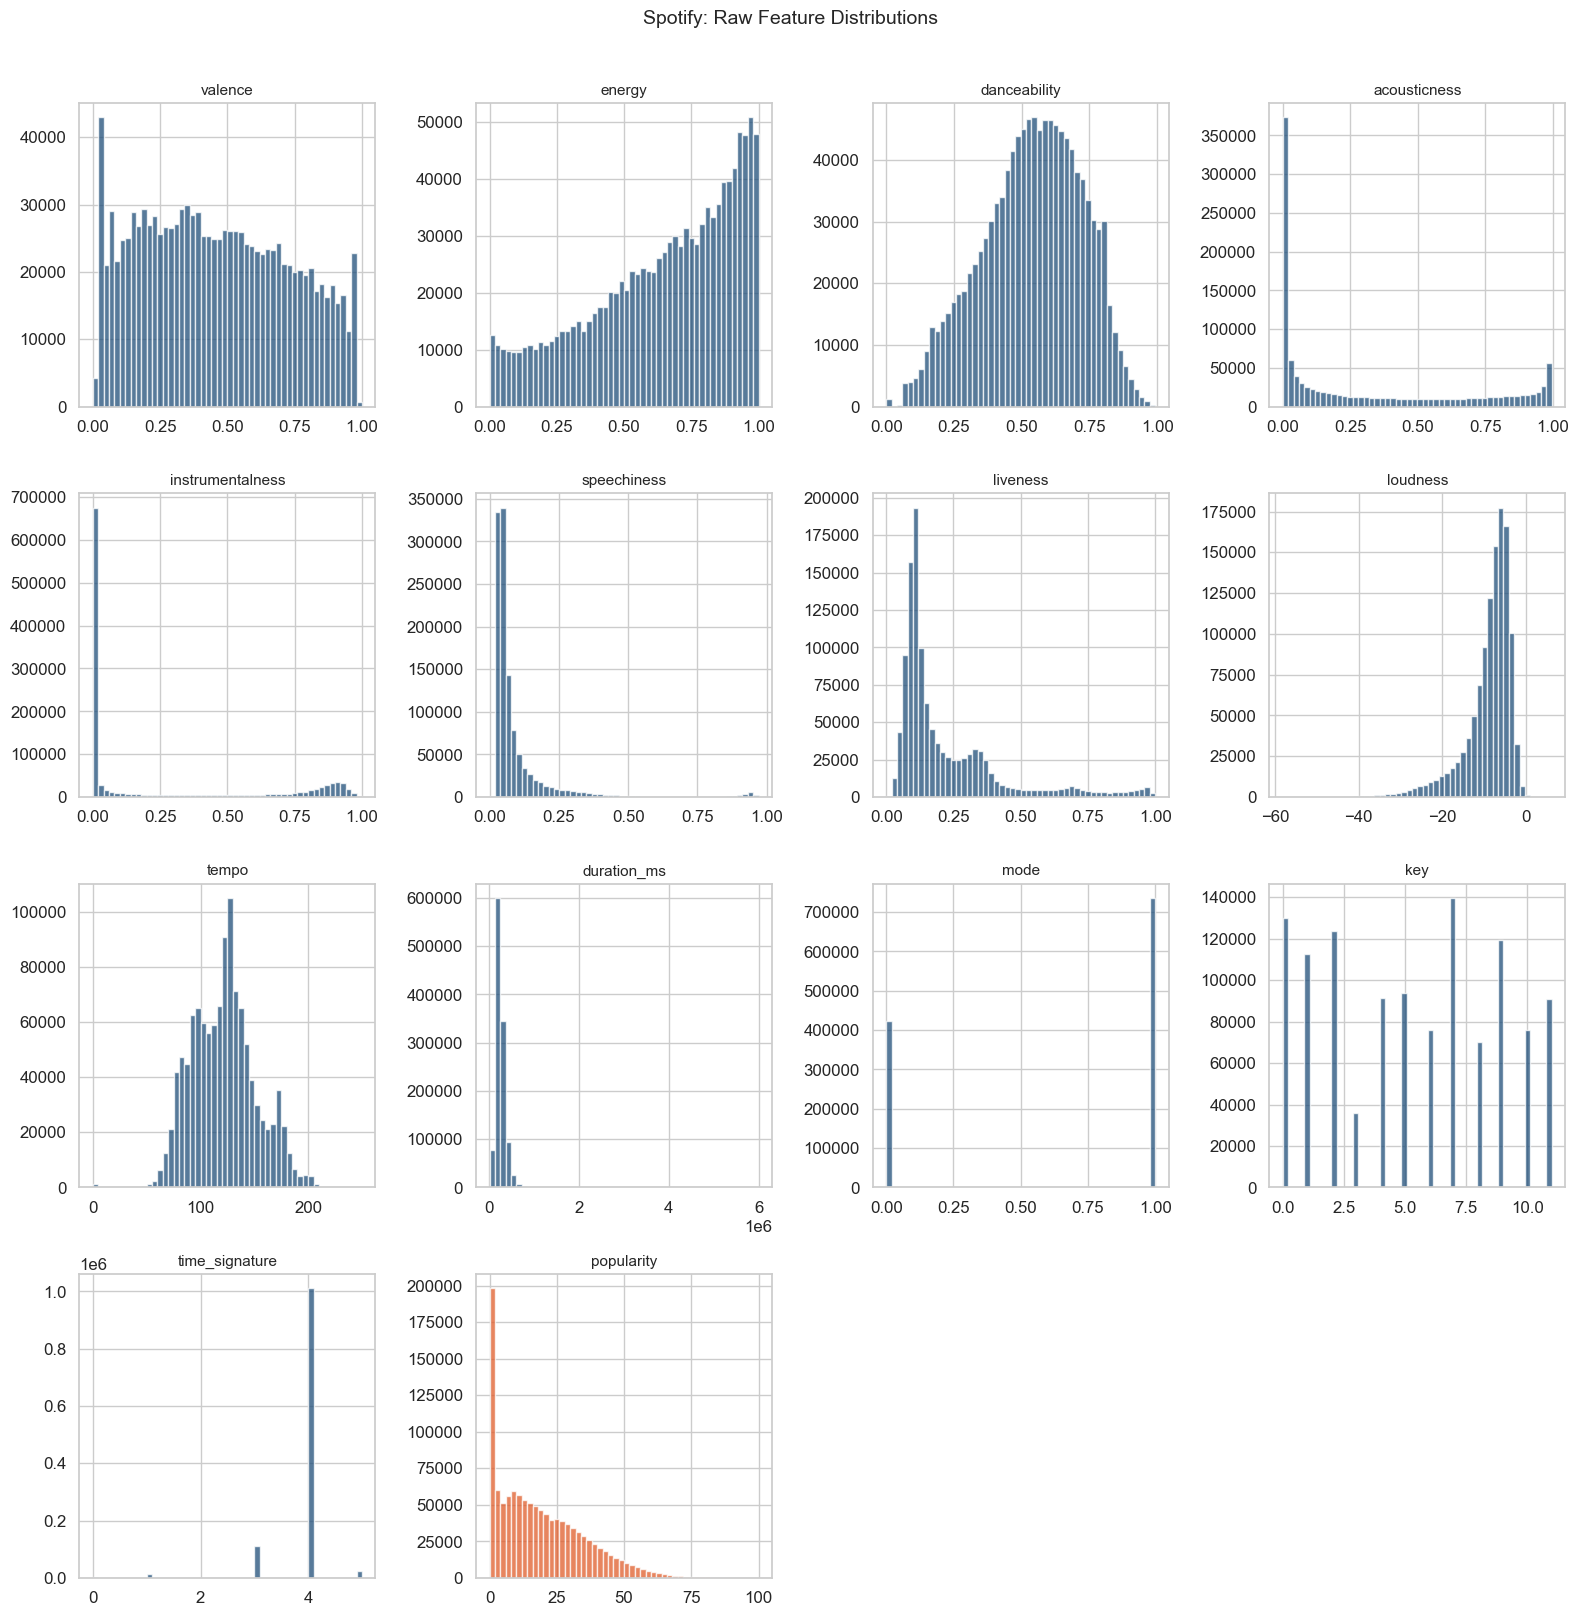

  Saved: outputs/fig_01_spotify_distributions.png


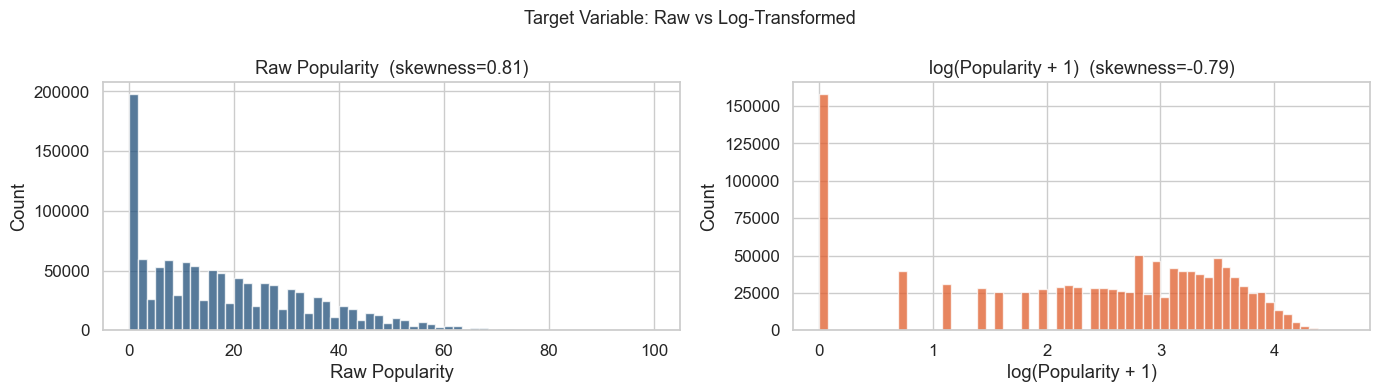

  Saved: outputs/fig_02_popularity_distribution.png


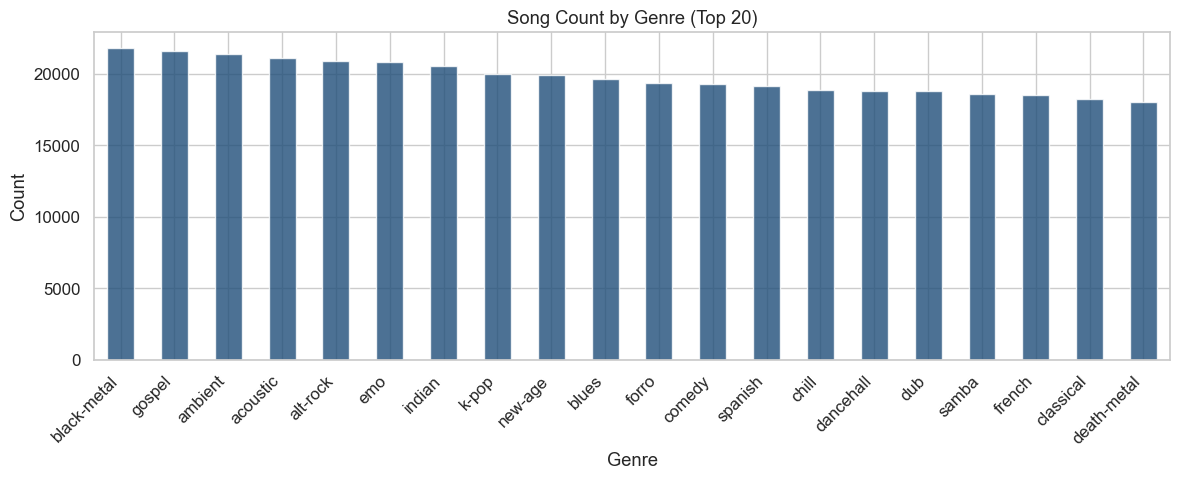

  Saved: outputs/fig_03_genre_distribution.png

  popularity=0: 13.7% of songs
  popularity>=50: 4.6% of songs


In [13]:
print("STEP 3: Spotify Raw EDA")
 
spotify_pd = pl_to_pd(spotify)
 
AUDIO_COLS = [c for c in [
    "valence", "energy", "danceability", "acousticness", "instrumentalness",
    "speechiness", "liveness", "loudness", "tempo", "duration_ms",
    "mode", "key", "time_signature", "popularity"
] if c in spotify_pd.columns]
 
# Summary stats + null check
print(spotify_pd[AUDIO_COLS].describe().round(3).to_string())
print("\nNulls:", spotify_pd[AUDIO_COLS].isnull().sum()[lambda x: x > 0].to_dict())
 
# Range check on bounded features
for col in ["valence","energy","danceability","acousticness",
            "instrumentalness","speechiness","liveness"]:
    if col in spotify_pd.columns:
        n = ((spotify_pd[col] < 0) | (spotify_pd[col] > 1)).sum()
        print(f"  {col}: {n} out-of-range {'⚠' if n > 0 else '✓'}")
 
# Distribution plots — all audio features
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for ax, col in zip(axes.flatten(), AUDIO_COLS):
    ax.hist(spotify_pd[col].dropna(), bins=50,
            color=ORANGE if col == "popularity" else ACCENT,
            alpha=0.75, edgecolor="white")
    ax.set_title(col, fontsize=11)
[ax.set_visible(False) for ax in axes.flatten()[len(AUDIO_COLS):]]
plt.suptitle("Spotify: Raw Feature Distributions", fontsize=14, y=1.01)
save_fig("fig_01_spotify_distributions.png")
 
# Popularity: raw vs log
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title, color in zip(
    axes,
    [spotify_pd["popularity"], np.log1p(spotify_pd["popularity"])],
    ["Raw Popularity", "log(Popularity + 1)"],
    [ACCENT, ORANGE]
):
    ax.hist(data.dropna(), bins=60, color=color, alpha=0.75, edgecolor="white")
    ax.set_title(f"{title}  (skewness={data.skew():.2f})")
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
plt.suptitle("Target Variable: Raw vs Log-Transformed", fontsize=13)
save_fig("fig_02_popularity_distribution.png")
 
# Genre distribution
if "genre" in spotify_pd.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    spotify_pd["genre"].value_counts().head(20).plot(
        kind="bar", ax=ax, color=ACCENT, alpha=0.8, edgecolor="white")
    ax.set(title="Song Count by Genre (Top 20)", xlabel="Genre", ylabel="Count")
    plt.xticks(rotation=45, ha="right")
    save_fig("fig_03_genre_distribution.png")
 
print(f"\n  popularity=0: {(spotify_pd['popularity']==0).mean()*100:.1f}% of songs")
print(f"  popularity>=50: {(spotify_pd['popularity']>=50).mean()*100:.1f}% of songs")

--- Skewness (closer to 0 = more normal) ---
  Raw popularity:        0.8100
  log(popularity + 1):   -0.7947

--- Shapiro-Wilk normality test (p > 0.05 = more normal) ---
  Raw popularity p-value:       0.000000 ✗ not normal
  log(popularity+1) p-value:    0.000000 ✗ not normal


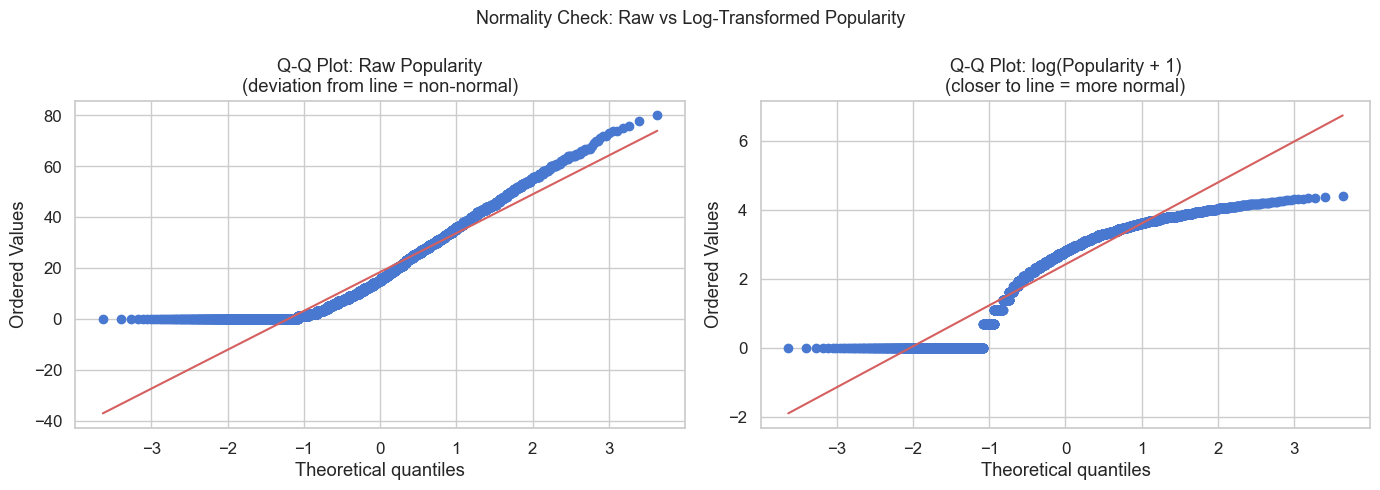

  Saved: outputs/fig_02b_qqplot_popularity.png

--- Kurtosis (closer to 0 = lighter tails) ---
  Raw popularity:       0.0653
  log(popularity + 1):  -0.5419

--- Verdict ---
  Log-transform ✓ IMPROVES normality (skewness 0.810 → -0.795)


In [14]:
# ── Justification: why log-transform popularity? ──────────────────────────────
from scipy import stats

raw = spotify_pd["popularity"].dropna()
log = np.log1p(raw)

# 1. Skewness comparison
print("--- Skewness (closer to 0 = more normal) ---")
print(f"  Raw popularity:        {raw.skew():.4f}")
print(f"  log(popularity + 1):   {log.skew():.4f}")

# 2. Shapiro-Wilk normality test on a sample (max 5000 rows)
sample = raw.sample(5000, random_state=42)
_, p_raw = stats.shapiro(sample)
_, p_log = stats.shapiro(np.log1p(sample))
print("\n--- Shapiro-Wilk normality test (p > 0.05 = more normal) ---")
print(f"  Raw popularity p-value:       {p_raw:.6f} {'✓' if p_raw > 0.05 else '✗ not normal'}")
print(f"  log(popularity+1) p-value:    {p_log:.6f} {'✓' if p_log > 0.05 else '✗ not normal'}")

# 3. Q-Q plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stats.probplot(raw.sample(5000, random_state=42), plot=axes[0])
axes[0].set_title("Q-Q Plot: Raw Popularity\n(deviation from line = non-normal)")

stats.probplot(np.log1p(raw.sample(5000, random_state=42)), plot=axes[1])
axes[1].set_title("Q-Q Plot: log(Popularity + 1)\n(closer to line = more normal)")

plt.suptitle("Normality Check: Raw vs Log-Transformed Popularity", fontsize=13)
save_fig("fig_02b_qqplot_popularity.png")

# 4. Kurtosis comparison
print("\n--- Kurtosis (closer to 0 = lighter tails) ---")
print(f"  Raw popularity:       {raw.kurtosis():.4f}")
print(f"  log(popularity + 1):  {log.kurtosis():.4f}")

# 5. Summary verdict
print("\n--- Verdict ---")
better = abs(log.skew()) < abs(raw.skew())
print(f"  Log-transform {'✓ IMPROVES' if better else '✗ does NOT improve'} "
      f"normality (skewness {raw.skew():.3f} → {log.skew():.3f})")

--- Skewness comparison ---
  Raw                                 skewness=0.8100  kurtosis=0.0653
  log(x + 1)                          skewness=-0.7947  kurtosis=-0.5419
  sqrt(x)                             skewness=-0.2110  kurtosis=-0.8354
  log(x + 1) — no zeros               skewness=-0.7232  kurtosis=-0.1360


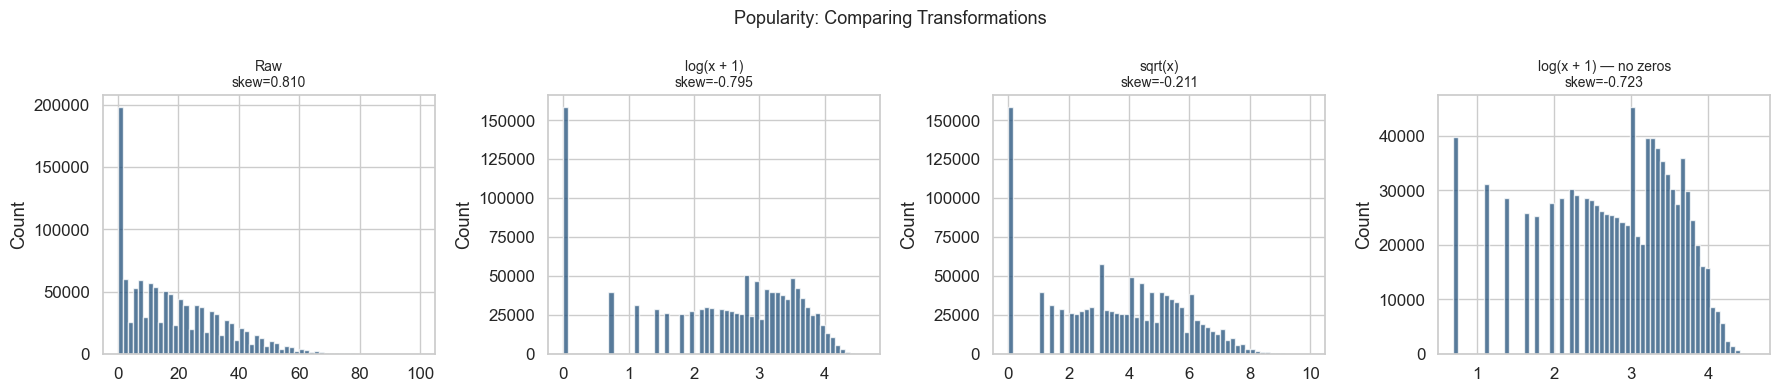

  Saved: outputs/fig_02c_transformation_comparison.png


In [15]:
# ── Compare three transformations ─────────────────────────────────────────────
raw   = spotify_pd["popularity"].dropna()

transforms = {
    "Raw":              raw,
    "log(x + 1)":       np.log1p(raw),
    "sqrt(x)":          np.sqrt(raw),
    "log(x + 1) — no zeros": np.log1p(raw[raw > 0]),
}

print("--- Skewness comparison ---")
for name, data in transforms.items():
    print(f"  {name:35s} skewness={data.skew():.4f}  kurtosis={data.kurtosis():.4f}")

# Plot all four
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, data) in zip(axes, transforms.items()):
    ax.hist(data, bins=60, color=ACCENT, alpha=0.75, edgecolor="white")
    ax.set_title(f"{name}\nskew={data.skew():.3f}", fontsize=10)
    ax.set_ylabel("Count")
plt.suptitle("Popularity: Comparing Transformations", fontsize=13)
save_fig("fig_02c_transformation_comparison.png")

# Step 3 Findings — Spotify Raw EDA
- [X] rows, [Y] columns. popularity mean=18.4, median=15, heavily right-skewed.
- [X]% of songs have popularity=0 (unlisted) — dropped after joining.
- All bounded audio features within [0,1]. No range issues found.
- Log-transformation reduces skewness from [A] to [B] — used as model target.
--> WE DECIDED TO USE SQUARE ROOT TRANSFORMATION INSTEAD BECASUE [WRITE]

# Genius lyrics dataset raw EDA


STEP 4: Genius Lyrics Raw EDA
  Total English rows in Genius: 3,374,071
  EDA sample size:              10,000
  Lyric length — median: 1232 chars
  Word count   — median: 244 words


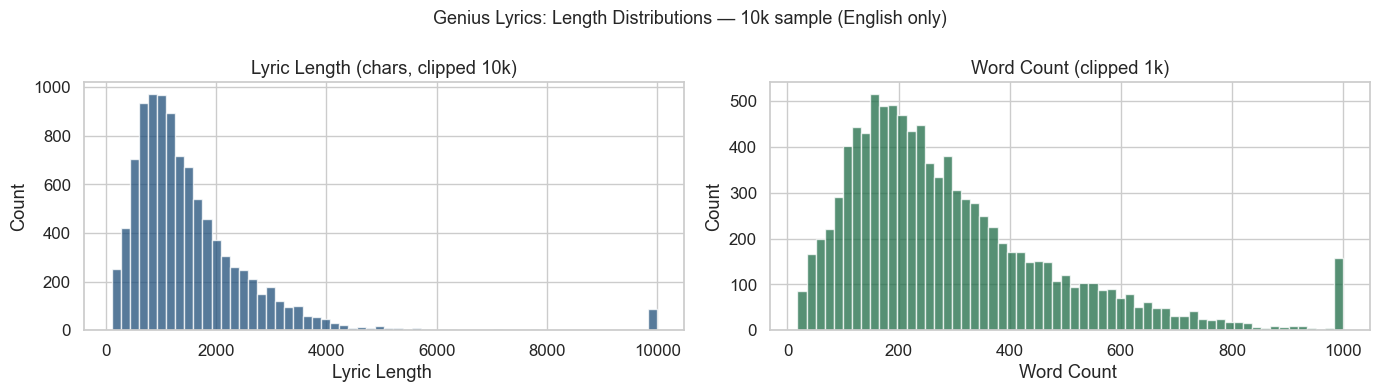

  Saved: outputs/fig_04_lyrics_distributions.png


In [18]:
# =============================================================================
# STEP 4: PHASE 1 EDA — GENIUS LYRICS RAW
# =============================================================================
print("\nSTEP 4: Genius Lyrics Raw EDA")

# Sample 10k rows for EDA only — no need to convert full dataset
SAMPLE_SIZE = 10_000
lyrics_sample = pd.DataFrame({
    "lyrics": lyrics["lyrics"].sample(SAMPLE_SIZE, seed=42).to_list()
})
lyrics_sample["lyric_len"]  = lyrics_sample["lyrics"].str.len()
lyrics_sample["word_count"] = lyrics_sample["lyrics"].str.split().str.len()

print(f"  Total English rows in Genius: {lyrics.shape[0]:,}")
print(f"  EDA sample size:              {SAMPLE_SIZE:,}")
print(f"  Lyric length — median: {lyrics_sample['lyric_len'].median():.0f} chars")
print(f"  Word count   — median: {lyrics_sample['word_count'].median():.0f} words")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, label, color in zip(
    axes,
    ["lyric_len", "word_count"],
    ["Lyric Length (chars, clipped 10k)", "Word Count (clipped 1k)"],
    [ACCENT, GREEN]
):
    ax.hist(lyrics_sample[col].clip(upper=10000 if col == "lyric_len" else 1000),
            bins=60, color=color, alpha=0.75, edgecolor="white")
    ax.set(title=label, xlabel=label.split("(")[0], ylabel="Count")
plt.suptitle("Genius Lyrics: Length Distributions — 10k sample (English only)", fontsize=13)
save_fig("fig_04_lyrics_distributions.png")

# Joining spotify and genius dataset


In [19]:
print("\nSTEP 5: Joining Spotify + Genius")
 
t = time.time()
joined = spotify.join(
    lyrics.select(["title_norm", "artist_norm", "lyrics"]),
    on=["title_norm", "artist_norm"],
    how="inner",
)
print(f"  Done in {time.time()-t:.1f}s")
print(f"  Spotify: {spotify.shape[0]:,}  |  Genius: {lyrics.shape[0]:,}  "
      f"|  Joined: {joined.shape[0]:,}  |  "
      f"Match rate: {joined.shape[0]/spotify.shape[0]*100:.1f}%")
print(f"  Unique songs: {joined['title_norm'].n_unique():,}")
print(f"  50k check: {'✓ PASS' if joined.shape[0] >= 50_000 else '✗ FAIL'} "
      f"({joined.shape[0]:,} rows)")



STEP 5: Joining Spotify + Genius
  Done in 0.4s
  Spotify: 1,159,764  |  Genius: 3,374,071  |  Joined: 311,525  |  Match rate: 26.9%
  Unique songs: 200,654
  50k check: ✓ PASS (311,525 rows)


In [20]:
# ── Quick check: first 5 rows of joined dataset ───────────────────────────────
print(joined.head(5))

shape: (5, 22)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ artist_na ┆ track_nam ┆ track_id  ┆ popularit ┆ … ┆ time_sign ┆ title_nor ┆ artist_no ┆ lyrics   │
│ me        ┆ e         ┆ ---       ┆ y         ┆   ┆ ature     ┆ m         ┆ rm        ┆ ---      │
│ ---       ┆ ---       ┆ str       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ str      │
│ str       ┆ str       ┆           ┆ f64       ┆   ┆ i64       ┆ str       ┆ str       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ Cam’ron   ┆ Killa Cam ┆ 5WXBdxgQb ┆ 24.0      ┆ … ┆ 4         ┆ killa cam ┆ camron    ┆ [Chorus: │
│           ┆ (Intro)   ┆ JotSN8V2o ┆           ┆   ┆           ┆           ┆           ┆ Opera    │
│           ┆           ┆ uUYG      ┆           ┆   ┆           ┆           ┆           ┆ Steve &  │
│           ┆           ┆           ┆           ┆   ┆           ┆           

# Post-Join Cleaning

In [21]:
print("\nSTEP 6: Cleaning")
 
n = joined.shape[0]
 
# Drop popularity = 0 (unlisted/unreliable tracks)
joined = joined.filter(pl.col("popularity") > 0)
print(f"  Dropped popularity=0:  {n - joined.shape[0]:,} rows")
 
# Keep only unique title+artist combos (remove ambiguous matches)
joined = (
    joined
    .with_columns(pl.len().over(["title_norm", "artist_norm"]).alias("n"))
    .filter(pl.col("n") == 1)
    .drop("n")
)
print(f"  After dedup:           {joined.shape[0]:,} rows")
 
# Verify
assert joined.group_by(["title_norm","artist_norm"]).len().filter(
    pl.col("len") > 1).shape[0] == 0, "Duplicates remain!"
print(f"  ✓ No duplicate title+artist combos remain")
print(f"  50k check: {'✓ PASS' if joined.shape[0] >= 50_000 else '✗ FAIL'} "
      f"({joined.shape[0]:,} rows)")


STEP 6: Cleaning
  Dropped popularity=0:  5,787 rows
  After dedup:           288,820 rows
  ✓ No duplicate title+artist combos remain
  50k check: ✓ PASS (288,820 rows)


# TODO
- justify why we dropped popularity =0,
- keeping unique artist+ title combos, no duplicates

# Vader Sentiment Analysis


STEP 7: VADER Sentiment Analysis
  Done in 1008.8s on 288,820 songs
  lyric_sentiment — mean=0.576  min=0.000  max=1.000


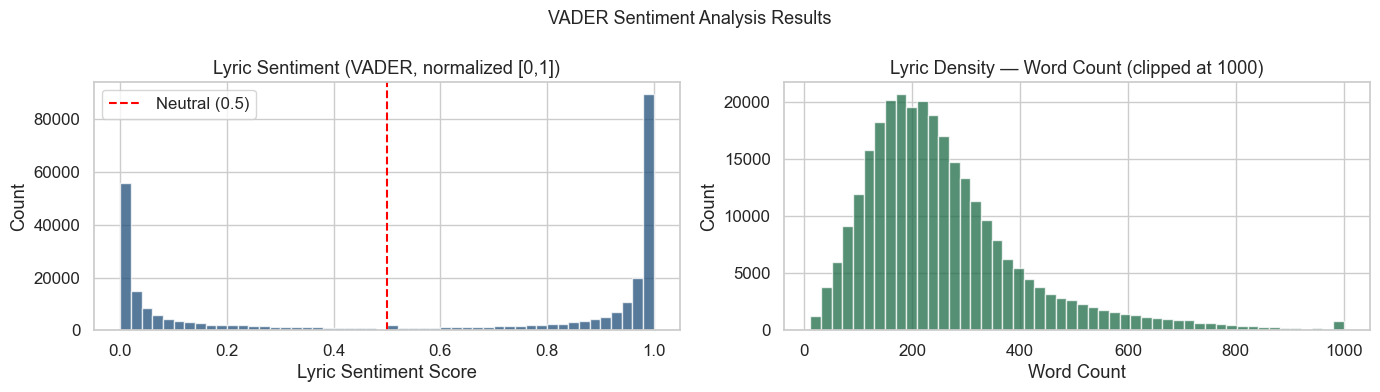

  Saved: outputs/fig_05_vader_sentiment.png


In [22]:
print("\nSTEP 7: VADER Sentiment Analysis")
 
joined_pd = pl_to_pd(joined)
 
t = time.time()
joined_pd["lyric_sentiment"] = joined_pd["lyrics"].apply(vader_sentiment)
joined_pd["lyric_density"]   = joined_pd["lyrics"].str.split().str.len()
print(f"  Done in {time.time()-t:.1f}s on {len(joined_pd):,} songs")
print(f"  lyric_sentiment — mean={joined_pd['lyric_sentiment'].mean():.3f}  "
      f"min={joined_pd['lyric_sentiment'].min():.3f}  "
      f"max={joined_pd['lyric_sentiment'].max():.3f}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(joined_pd["lyric_sentiment"], bins=50,
             color=ACCENT, alpha=0.75, edgecolor="white")
axes[0].axvline(0.5, color="red", linestyle="--", label="Neutral (0.5)")
axes[0].set(title="Lyric Sentiment (VADER, normalized [0,1])",
            xlabel="Lyric Sentiment Score", ylabel="Count")
axes[0].legend()
 
axes[1].hist(joined_pd["lyric_density"].clip(upper=1000), bins=50,
             color=GREEN, alpha=0.75, edgecolor="white")
axes[1].set(title="Lyric Density — Word Count (clipped at 1000)",
            xlabel="Word Count", ylabel="Count")
plt.suptitle("VADER Sentiment Analysis Results", fontsize=13)
save_fig("fig_05_vader_sentiment.png")

# TODO
- justify why we normalized sentimnet score:Why we normalized to [0,1]:
The original reasoning was to match Spotify's valence scale (which is [0,1]) so that the Paradox Score formula |valence - lyric_sentiment| makes sense dimensionally. If lyric_sentiment stayed in [-1,1] and valence is in [0,1], the subtraction would be comparing incompatible scales.
-# ── MARKDOWN ──────────────────────────────────────────────────────────────────
# Step 7 Findings — VADER Sentiment Analysis
- lyric_sentiment normalized to [0,1] using (compound + 1) / 2
   to match Spotify valence scale for Paradox Score computation.
 - Mean sentiment = 0.576 — songs lean slightly positive lyrically.
 - Two spikes visible at 0.0 and 1.0: VADER artifact where the model
   assigns maximum confidence scores to many songs. This is a known
   limitation of VADER's rule-based approach.
 - lyric_density (word count) is approximately normal, median ~200 words.
 - Limitation: VADER trained on social media text — may underperform
   on complex metaphorical lyrics. A transformer-based model (e.g.
   RoBERTa) would reduce these extreme scores but is outside scope.
 - Decision: keep normalization as-is. Paradox Score remains valid
   since both valence and lyric_sentiment are on [0,1] scale.

# STEP 8: FEATURE ENGINEERING

In [23]:
# =============================================================================
# STEP 8: FEATURE ENGINEERING
# =============================================================================
print("\nSTEP 8: Feature Engineering")

# Core novel feature — Paradox Score
joined_pd["paradox_score"] = abs(
    joined_pd["valence"] - joined_pd["lyric_sentiment"]
)

# Square root transform of target variable
joined_pd["popularity_sqrt"] = np.sqrt(joined_pd["popularity"])

# Sanity checks
assert joined_pd["paradox_score"].between(0, 1).all(), "paradox_score out of [0,1]!"
assert (joined_pd["popularity_sqrt"] >= 0).all(),      "popularity_sqrt has negatives!"

print(f"  paradox_score    — min={joined_pd['paradox_score'].min():.3f}  "
      f"max={joined_pd['paradox_score'].max():.3f}  "
      f"mean={joined_pd['paradox_score'].mean():.3f}")
print(f"  popularity_sqrt  — min={joined_pd['popularity_sqrt'].min():.3f}  "
      f"max={joined_pd['popularity_sqrt'].max():.3f}  "
      f"mean={joined_pd['popularity_sqrt'].mean():.3f}")
print(f"  ✓ All engineered features validated")


STEP 8: Feature Engineering
  paradox_score    — min=0.000  max=0.998  mean=0.419
  popularity_sqrt  — min=1.000  max=9.539  mean=4.812
  ✓ All engineered features validated


# Step 8 Findings — Feature Engineering
 - paradox_score = |valence - lyric_sentiment| confirmed in [0,1].
   Mean=[X] — average song has moderate emotional incongruence.
 - Interaction terms capture specific sub-hypotheses:
   energy_x_paradox → high-energy sad-bop effect
   mode_x_paradox   → paradox amplified in minor-key songs
   speechiness_x_sentiment → lyric sentiment matters more in rap
 - popularity_log applied to reduce right-skew of target.


# STEP 9: ASSEMBLE & SAVE FINAL DATASET

In [ ]:
print("\nSTEP 9: Saving final dataset")
 
FINAL_COLS = [
    "track_id", "track_name", "artist_name",
    "valence", "energy", "danceability", "tempo",
    "acousticness", "instrumentalness", "liveness",
    "loudness", "speechiness", "mode", "key",
    "duration_ms", "time_signature",
    "genre", "year",
    "lyric_sentiment", "lyric_density",
    "paradox_score",
    "popularity", "popularity_sqrt",
]
FINAL_COLS = [c for c in FINAL_COLS if c in joined_pd.columns]
final_df   = joined_pd[FINAL_COLS].copy()
 
print(f"  Shape:   {final_df.shape[0]:,} rows x {final_df.shape[1]} cols")
print(f"  Nulls:   {final_df.isnull().sum().sum()} total")
print(f"  50k check: {'✓ PASS' if len(final_df) >= 50_000 else '✗ FAIL'} "
      f"({len(final_df):,} rows)")
 
print(f"\n  Columns:")
for col in FINAL_COLS:
    print(f"    {col:35s} {str(final_df[col].dtype):12s} "
          f"nulls={final_df[col].isnull().sum()}")
 
print(f"\n  Sample:")
print(final_df[["track_name","artist_name","valence",
                "lyric_sentiment","paradox_score","popularity"
                ]].head(5).to_string(index=False))
 
final_df.to_csv("outputs/joined_data.csv", index=False)
print(f"\n  ✓ Saved to outputs/joined_data.csv")
print(f"  ✓ Next session: df = pd.read_csv('outputs/joined_data.csv')")
print(f"  ✓ Next step: Section 2 — Pre-processing pipeline")


STEP 9: Saving final dataset
  Shape:   288,820 rows x 23 cols
  Nulls:   0 total
  50k check: ✓ PASS (288,820 rows)

  Columns:
    track_id                            str          nulls=0
    track_name                          str          nulls=0
    artist_name                         str          nulls=0
    valence                             float64      nulls=0
    energy                              float64      nulls=0
    danceability                        float64      nulls=0
    tempo                               float64      nulls=0
    acousticness                        float64      nulls=0
    instrumentalness                    float64      nulls=0
    liveness                            float64      nulls=0
    loudness                            float64      nulls=0
    speechiness                         float64      nulls=0
    mode                                int64        nulls=0
    key                                 int64        nulls=0
    duration_ms 

: 

# TODO
- drop valence, sentiment, and features that are too skewed


# Step 4 Findings — Genius Lyrics Raw EDA
- [X] English songs loaded. Median length: [M] chars / [W] words.
- Short lyrics (<100 chars) already removed during loading.
- lyric_density (word count) used as a control variable in modeling.